In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Alle Bibliotheken erfolgreich geladen!")

Alle Bibliotheken erfolgreich geladen!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten laden
df = pd.read_csv('Unfallorte2022_LinRef.csv', sep=';', encoding='latin1')

# Erste Übersicht
print("Anzahl Unfälle:", len(df))
print("\nSpalten:")
print(df.columns.tolist())
print("\nErste 5 Zeilen:")
df.head()

Anzahl Unfälle: 256492

Spalten:
['OBJECTID', 'UIDENTSTLAE', 'ULAND', 'UREGBEZ', 'UKREIS', 'UGEMEINDE', 'UJAHR', 'UMONAT', 'USTUNDE', 'UWOCHENTAG', 'UKATEGORIE', 'UART', 'UTYP1', 'ULICHTVERH', 'IstStrassenzustand', 'IstRad', 'IstPKW', 'IstFuss', 'IstKrad', 'IstGkfz', 'IstSonstige', 'LINREFX', 'LINREFY', 'XGCSWGS84', 'YGCSWGS84']

Erste 5 Zeilen:


C:\Users\Ferhat\AppData\Local\Temp\ipykernel_32264\624369690.py:6: DtypeWarning: Columns (0: UIDENTSTLAE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Unfallorte2022_LinRef.csv', sep=';', encoding='latin1')


,OBJECTID,UIDENTSTLAE,ULAND,UREGBEZ,UKREIS,UGEMEINDE,UJAHR,UMONAT,USTUNDE,UWOCHENTAG,...,IstRad,IstPKW,IstFuss,IstKrad,IstGkfz,IstSonstige,LINREFX,LINREFY,XGCSWGS84,YGCSWGS84
0,1,1220204125013262022,1,0,54,84,2022,2,19,6,...,1,1,0,0,0,0,"506085,644000001018867","6035085,351999809965491","9,093886180000030","54,463395769999998"
1,2,1220529134013152022,1,0,57,44,2022,5,11,1,...,0,0,0,1,0,0,"593821,621226734016091","6014331,532445689663291","10,440636083000101","54,268303975000002"
2,3,1220508125013982022,1,0,59,73,2022,5,12,1,...,0,1,0,0,0,0,"540417,076000001979992","6045563,334999830462039","9,624949321000029","54,555985573000001"
3,4,1220517152013752022,1,0,3,0,2022,5,8,3,...,1,0,0,0,0,0,"609966,338422868051566","5970404,848156260326505","10,672490491000101","53,870453103000003"
4,5,1220426181013142022,1,0,61,46,2022,4,19,3,...,1,0,0,0,0,0,"533425,841011611977592","5975832,250405009835958","9,509078523000030","53,929808971999996"


C:\Users\Ferhat\AppData\Local\Temp\ipykernel_32264\3271708257.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='UWOCHENTAG_NAME', order=reihenfolge, palette='Blues_d')


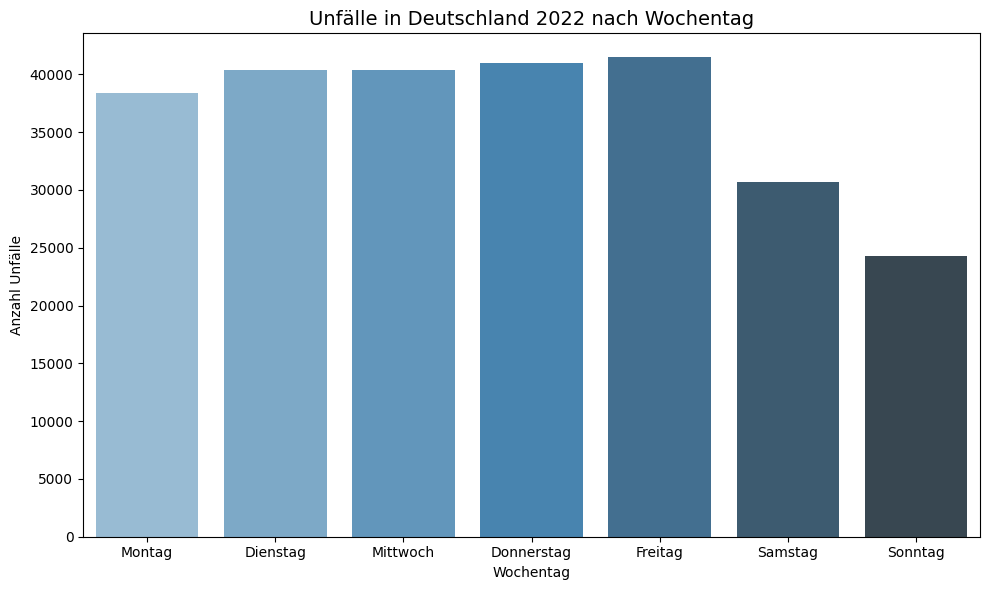

In [2]:
# Unfälle nach Wochentag
plt.figure(figsize=(10, 6))
wochentage = {1: 'Sonntag', 2: 'Montag', 3: 'Dienstag', 4: 'Mittwoch', 
              5: 'Donnerstag', 6: 'Freitag', 7: 'Samstag'}
df['UWOCHENTAG_NAME'] = df['UWOCHENTAG'].map(wochentage)
reihenfolge = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

sns.countplot(data=df, x='UWOCHENTAG_NAME', order=reihenfolge, palette='Blues_d')
plt.title('Unfälle in Deutschland 2022 nach Wochentag', fontsize=14)
plt.xlabel('Wochentag')
plt.ylabel('Anzahl Unfälle')
plt.tight_layout()
plt.savefig('unfaelle_wochentag.png')
plt.show()

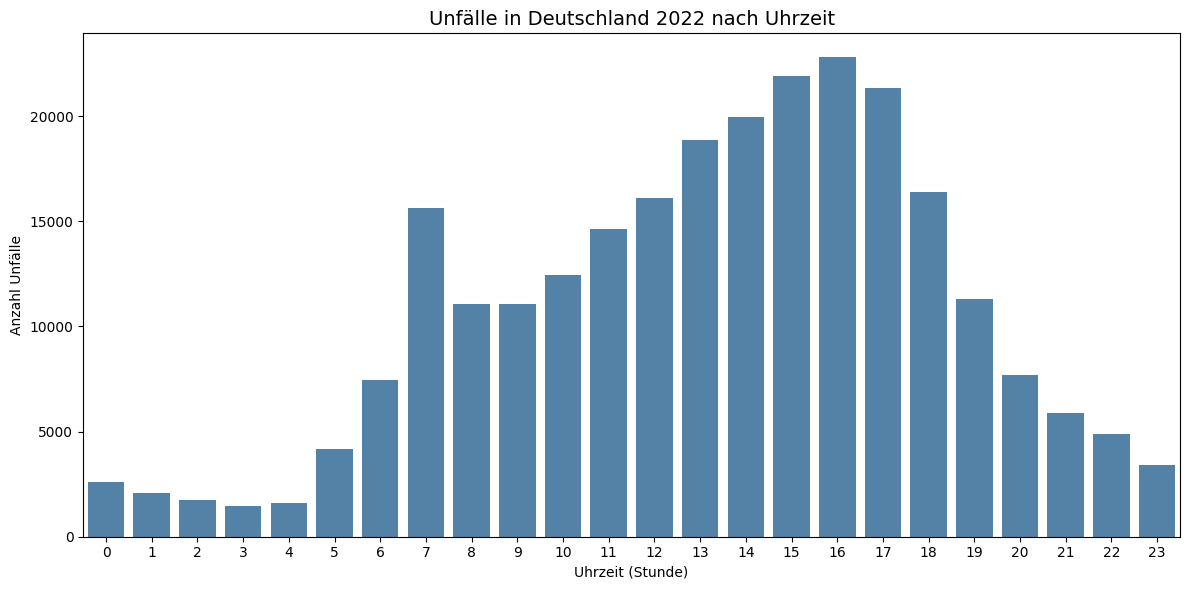

In [3]:
# Unfälle nach Uhrzeit
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='USTUNDE', color='steelblue')
plt.title('Unfälle in Deutschland 2022 nach Uhrzeit', fontsize=14)
plt.xlabel('Uhrzeit (Stunde)')
plt.ylabel('Anzahl Unfälle')
plt.tight_layout()
plt.savefig('unfaelle_uhrzeit.png')
plt.show()

In [2]:
# Verbesserte Grafik - Unfälle nach Wochentag
fig, ax = plt.subplots(figsize=(12, 7))

wochentage = {1: 'Sonntag', 2: 'Montag', 3: 'Dienstag', 4: 'Mittwoch', 
              5: 'Donnerstag', 6: 'Freitag', 7: 'Samstag'}
df['UWOCHENTAG_NAME'] = df['UWOCHENTAG'].map(wochentage)
reihenfolge = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

counts = df['UWOCHENTAG_NAME'].value_counts().reindex(reihenfolge)

farben = ['#2196F3' if tag != 'Freitag' else '#F44336' for tag in reihenfolge]

balken = ax.bar(reihenfolge, counts.values, color=farben, edgecolor='white', linewidth=0.5)

for balken_element in balken:
    hoehe = balken_element.get_height()
    ax.text(balken_element.get_x() + balken_element.get_width()/2., hoehe + 200,
            f'{int(hoehe):,}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Verkehrsunfälle in Deutschland 2022\nnach Wochentag', 
             fontsize=16, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('Wochentag', fontsize=12, color='#444444')
ax.set_ylabel('Anzahl Unfälle', fontsize=12, color='#444444')
ax.set_ylim(0, counts.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

ax.annotate('⚠ Freitag: Höchste Unfallzahl', xy=(4, counts['Freitag']), 
            xytext=(5.2, counts['Freitag'] - 3000),
            fontsize=10, color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336'))

plt.tight_layout()
plt.savefig('unfaelle_wochentag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")

NameError: name 'plt' is not defined

C:\Users\Ferhat\AppData\Local\Temp\ipykernel_27564\3515771590.py:6: DtypeWarning: Columns (0: UIDENTSTLAE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Unfallorte2022_LinRef.csv', sep=';', encoding='latin1')


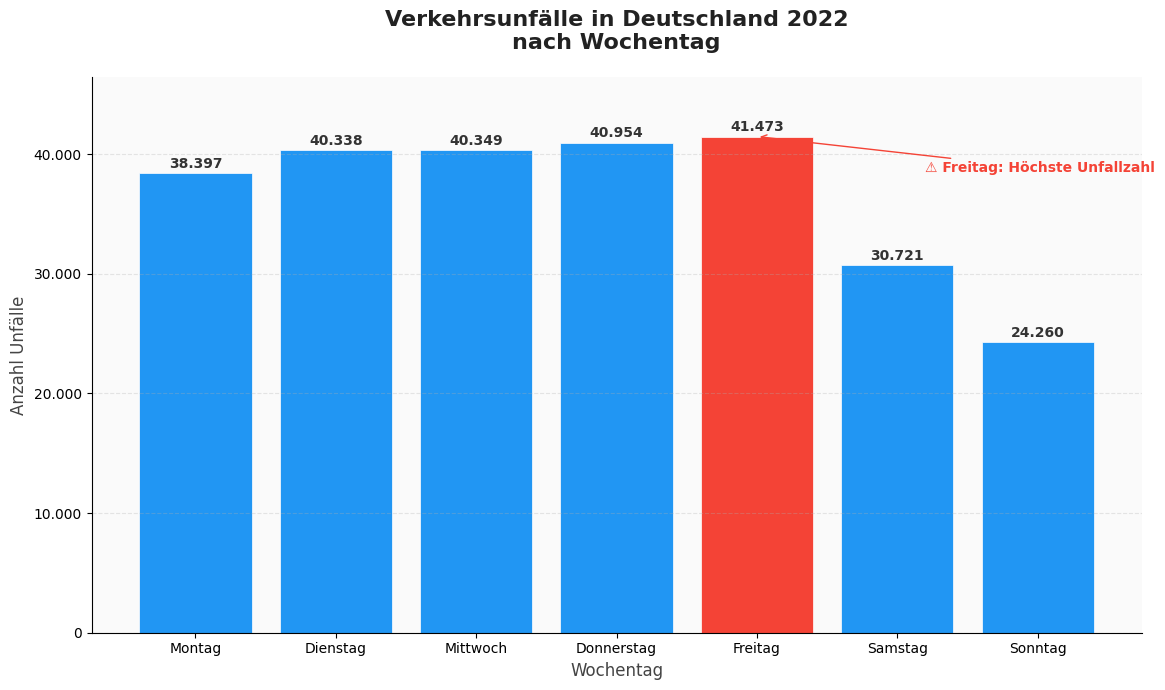

Gespeichert!


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Daten laden
df = pd.read_csv('Unfallorte2022_LinRef.csv', sep=';', encoding='latin1')

# Verbesserte Grafik - Unfälle nach Wochentag
fig, ax = plt.subplots(figsize=(12, 7))

wochentage = {1: 'Sonntag', 2: 'Montag', 3: 'Dienstag', 4: 'Mittwoch', 
              5: 'Donnerstag', 6: 'Freitag', 7: 'Samstag'}
df['UWOCHENTAG_NAME'] = df['UWOCHENTAG'].map(wochentage)
reihenfolge = ['Montag', 'Dienstag', 'Mittwoch', 'Donnerstag', 'Freitag', 'Samstag', 'Sonntag']

counts = df['UWOCHENTAG_NAME'].value_counts().reindex(reihenfolge)

farben = ['#2196F3' if tag != 'Freitag' else '#F44336' for tag in reihenfolge]

balken = ax.bar(reihenfolge, counts.values, color=farben, edgecolor='white', linewidth=0.5)

for balken_element in balken:
    hoehe = balken_element.get_height()
    ax.text(balken_element.get_x() + balken_element.get_width()/2., hoehe + 200,
            f'{int(hoehe):,}'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

ax.set_title('Verkehrsunfälle in Deutschland 2022\nnach Wochentag', 
             fontsize=16, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('Wochentag', fontsize=12, color='#444444')
ax.set_ylabel('Anzahl Unfälle', fontsize=12, color='#444444')
ax.set_ylim(0, counts.max() * 1.12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

ax.annotate('⚠ Freitag: Höchste Unfallzahl', xy=(4, counts['Freitag']), 
            xytext=(5.2, counts['Freitag'] - 3000),
            fontsize=10, color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336'))

plt.tight_layout()
plt.savefig('unfaelle_wochentag.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")

In [1]:
# Verbesserte Grafik - Unfälle nach Uhrzeit
fig, ax = plt.subplots(figsize=(14, 7))

stunden_counts = df['USTUNDE'].value_counts().sort_index()

farben = ['#F44336' if (15 <= s <= 17) else '#2196F3' for s in stunden_counts.index]

balken = ax.bar(stunden_counts.index, stunden_counts.values, color=farben, edgecolor='white', linewidth=0.5)

ax.set_title('Verkehrsunfälle in Deutschland 2022\nnach Uhrzeit', 
             fontsize=16, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('Uhrzeit (Stunde)', fontsize=12, color='#444444')
ax.set_ylabel('Anzahl Unfälle', fontsize=12, color='#444444')
ax.set_xticks(range(0, 24))
ax.set_ylim(0, stunden_counts.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

ax.annotate('⚠ Berufsverkehr\n15–17 Uhr', 
            xy=(16, stunden_counts[16]),
            xytext=(19, stunden_counts[16] - 2000),
            fontsize=10, color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336'))

plt.tight_layout()
plt.savefig('unfaelle_uhrzeit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")

NameError: name 'plt' is not defined

C:\Users\Ferhat\AppData\Local\Temp\ipykernel_17016\3151784041.py:5: DtypeWarning: Columns (0: UIDENTSTLAE) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Unfallorte2022_LinRef.csv', sep=';', encoding='latin1')


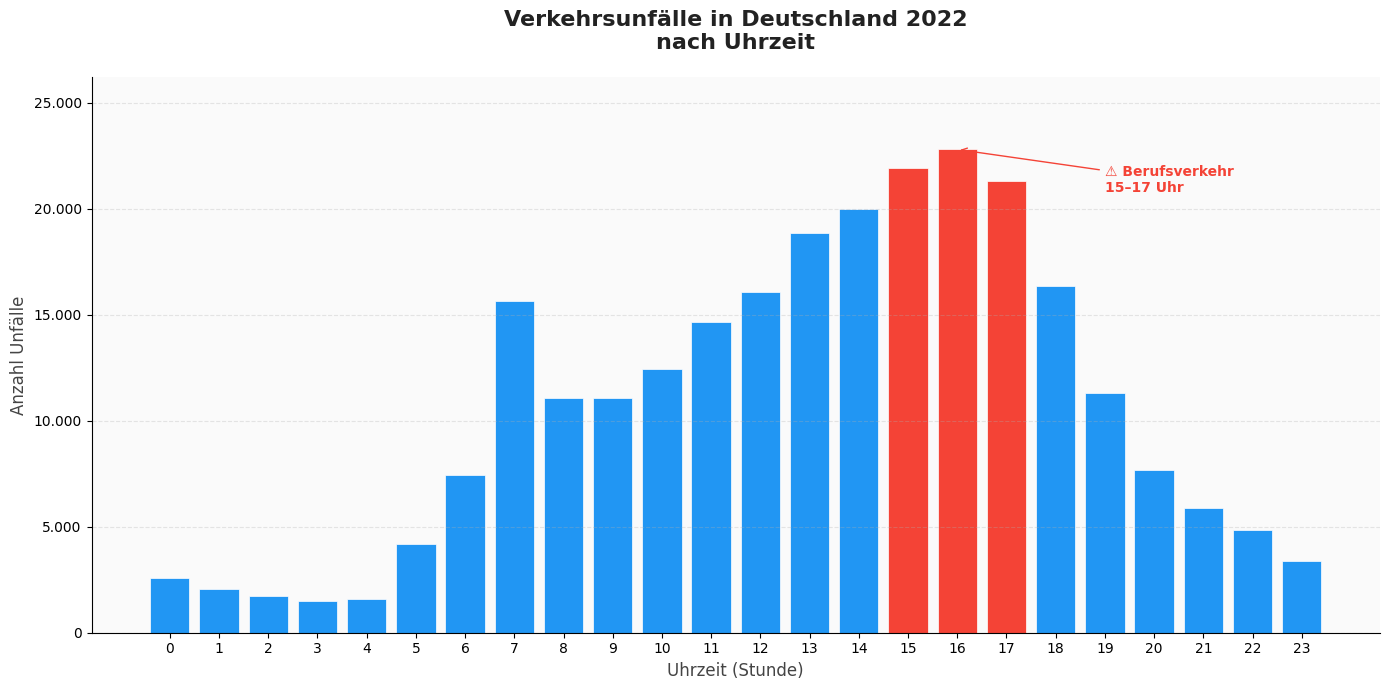

Gespeichert!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Daten laden
df = pd.read_csv('Unfallorte2022_LinRef.csv', sep=';', encoding='latin1')

# Verbesserte Grafik - Unfälle nach Uhrzeit
fig, ax = plt.subplots(figsize=(14, 7))

stunden_counts = df['USTUNDE'].value_counts().sort_index()

farben = ['#F44336' if (15 <= s <= 17) else '#2196F3' for s in stunden_counts.index]

balken = ax.bar(stunden_counts.index, stunden_counts.values, color=farben, edgecolor='white', linewidth=0.5)

ax.set_title('Verkehrsunfälle in Deutschland 2022\nnach Uhrzeit', 
             fontsize=16, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('Uhrzeit (Stunde)', fontsize=12, color='#444444')
ax.set_ylabel('Anzahl Unfälle', fontsize=12, color='#444444')
ax.set_xticks(range(0, 24))
ax.set_ylim(0, stunden_counts.max() * 1.15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'.replace(',', '.')))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

ax.annotate('⚠ Berufsverkehr\n15–17 Uhr', 
            xy=(16, stunden_counts[16]),
            xytext=(19, stunden_counts[16] - 2000),
            fontsize=10, color='#F44336', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#F44336'))

plt.tight_layout()
plt.savefig('unfaelle_uhrzeit.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gespeichert!")